In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('WA_Marketing-Campaign.csv')

In [3]:
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [5]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


In [6]:
mean_sales = df.groupby('Promotion')['SalesInThousands'].mean()
print('Mean Sales by Promotion')
print(mean_sales)

Mean Sales by Promotion
Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64


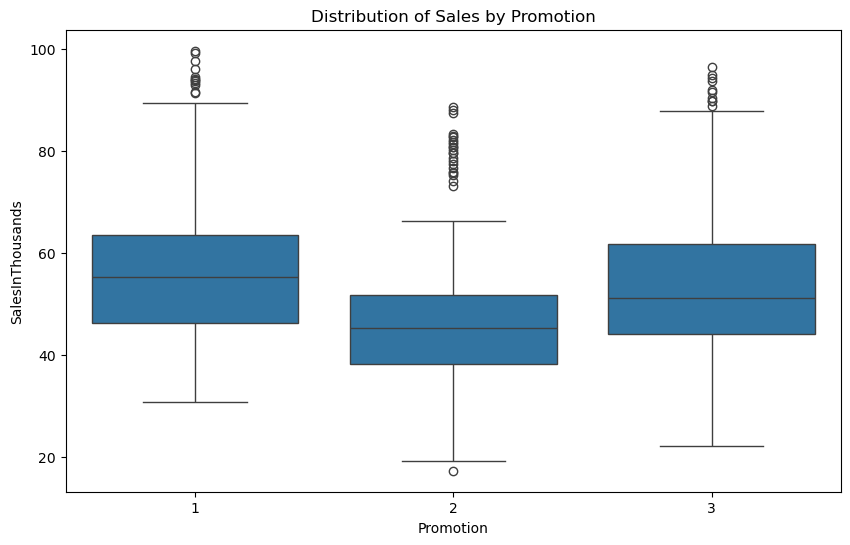

In [7]:
plt.figure(figsize=(10,6))
plt.title('Distribution of Sales by Promotion')
sns.boxplot( x='Promotion', y='SalesInThousands', data=df)
plt.show()

In [8]:
# ANOVA test
group1 = df[df['Promotion'] == 1]['SalesInThousands']
group2 = df[df['Promotion'] == 2]['SalesInThousands']
group3 = df[df['Promotion'] == 3]['SalesInThousands']

f_stat, p_value = stats.f_oneway(group1, group2, group3)
print(f"ANOVA: F-stat = {f_stat:.2f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("The differences are statistically significant")
else:
    print("The differences are not significant")

ANOVA: F-stat = 21.95, p-value = 0.0000
The differences are statistically significant


In [9]:
mean_by_market = df.groupby(['Promotion', 'MarketSize'])['SalesInThousands'].mean().unstack()
print("Average sales by market size:")
print(mean_by_market)

Average sales by market size:
MarketSize      Large     Medium      Small
Promotion                                  
1           75.235893  47.672604  60.162500
2           60.322031  39.114352  50.810625
3           77.203958  45.468879  59.514167


<function matplotlib.pyplot.show(close=None, block=None)>

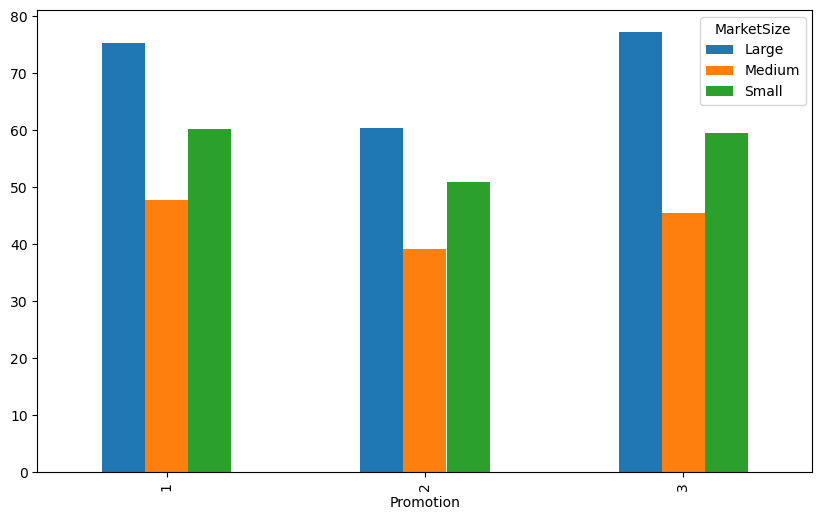

In [10]:
mean_by_market.plot(kind='bar', figsize=(10, 6))
plt.show

In [11]:
for promo in [1, 2, 3]:
    corr = df[df['Promotion'] == promo]['AgeOfStore'].corr(df[df['Promotion'] == promo]['SalesInThousands'])
    print(f"Correlation of store age and sales for Promotion {promo}: {corr:.2f}")

Correlation of store age and sales for Promotion 1: -0.14
Correlation of store age and sales for Promotion 2: 0.07
Correlation of store age and sales for Promotion 3: -0.05
